In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.include("..\\core\\constants.jl")
Main.include("..\\core\\setting.jl")
Main.include("..\\core\\alpha_s.jl") 

Main.include("..\\diff eqn.jl")

Main.eval("""
    using CSV
    using DataFrames 
    df_moments = CSV.read("../NP splitting grid/splitting_moments_grid.csv", DataFrame)
""")

Main.include("..\\NP splitting grid\\interpolation.jl")
Main.include("..\\NP splitting grid\\jet.jl")    

<PyCall.jlwrap Jg_NP_func>

In [3]:
Main.eval('αs_Z = 0.118')
b0 = 2*np.exp(-0.5772156649)

a1 = 2.31
a2 = 1.059

orders = [0, 1, 2]
order_labels = {0: 'LO', 1: 'NLO', 2: 'NNLO'}

In [4]:
kt_list = np.linspace(1.0, 20.0, 200)  # GeV^-1
μ = 91.2
order = 2

JqNP_array = []
JqNP_approx_array = []

for kt in tqdm(kt_list):
    JqNP_approx_array.append(Main.jet_kt_numerical(kt=kt, μ=μ, order=order, a1=a1, a2=a2))
    JqNP_array.append(Main.jet_kt_analytic(kt=kt, μ=μ, order=order, a1=a1, a2=a2))

100%|██████████| 200/200 [00:08<00:00, 24.61it/s]


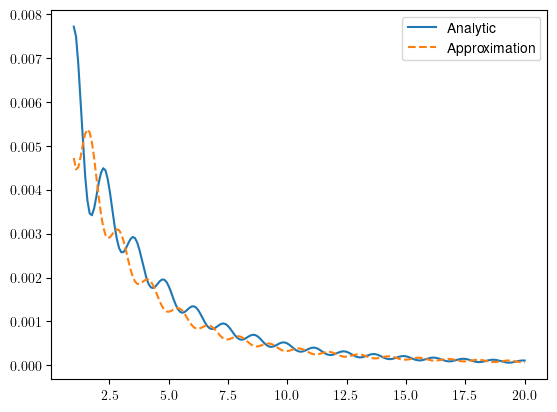

In [5]:
plt.plot(kt_list, JqNP_array, label='Analytic')
plt.plot(kt_list, JqNP_approx_array, label='Approximation', linestyle='dashed')
plt.legend()

In [6]:
mulist = np.logspace(np.log10(50.0), np.log10(400.0), 80)

kt1 = 1.0
kt2 = 20.0

kt1_numerical_arrays = {order: [] for order in orders}
kt2_numerical_arrays = {order: [] for order in orders}

kt1_analytical_arrays = {order: [] for order in orders}
kt2_analytical_arrays = {order: [] for order in orders}

for order in orders:
    Main.nloops_αs = order + 1
    for mu in tqdm(mulist):
        kt1_numerical = Main.jet_kt_numerical(kt=kt1, μ=mu, order=order, a1=a1, a2=a2)
        kt2_numerical = Main.jet_kt_numerical(kt=kt2, μ=mu, order=order, a1=a1, a2=a2)

        kt1_numerical_arrays[order].append(kt1_numerical)
        kt2_numerical_arrays[order].append(kt2_numerical)
        kt1_analytical = Main.jet_kt_analytic(kt=kt1, μ=mu, order=order, a1=a1, a2=a2)
        kt2_analytical = Main.jet_kt_analytic(kt=kt2, μ=mu, order=order, a1=a1, a2=a2)

        kt1_analytical_arrays[order].append(kt1_analytical)
        kt2_analytical_arrays[order].append(kt2_analytical)

for order in orders:
    kt1_numerical_norm = kt1_numerical_arrays[order][0]
    kt2_numerical_norm = kt2_numerical_arrays[order][0]

    kt1_numerical_arrays[order] = np.array(kt1_numerical_arrays[order]) / kt1_numerical_norm
    kt2_numerical_arrays[order] = np.array(kt2_numerical_arrays[order]) / kt2_numerical_norm

    kt1_analytical_norm = kt1_analytical_arrays[order][0]
    kt2_analytical_norm = kt2_analytical_arrays[order][0]

    kt1_analytical_arrays[order] = np.array(kt1_analytical_arrays[order]) / kt1_analytical_norm
    kt2_analytical_arrays[order] = np.array(kt2_analytical_arrays[order]) / kt2_analytical_norm


100%|██████████| 80/80 [00:04<00:00, 17.40it/s]


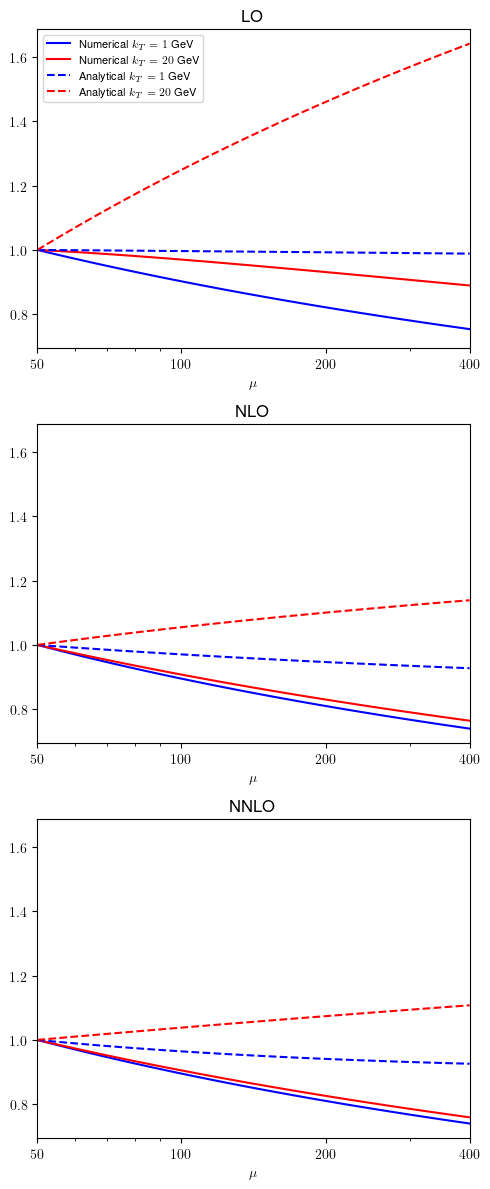

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter, NullFormatter

fig, axes = plt.subplots(3, 1, figsize=(5, 12), sharey=True)

for ax, order in zip(axes, orders):
    ax.plot(mulist, kt1_numerical_arrays[order], label=r'Numerical $k_T=1$ GeV', color='blue')
    ax.plot(mulist, kt2_numerical_arrays[order], label=r'Numerical $k_T=20$ GeV', color='red')

    ax.plot(mulist, kt1_analytical_arrays[order], '--', label=r'Analytical $k_T=1$ GeV', color='blue')
    ax.plot(mulist, kt2_analytical_arrays[order], '--', label=r'Analytical $k_T=20$ GeV', color='red')

    ax.set_title(order_labels[order])
    ax.set_xlabel(r'$\mu$')
    ax.set_xscale('log')
    ax.set_xlim(mulist[0], mulist[-1])
    ax.set_xticks([50, 100, 200, 400])
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(NullFormatter())

#axes[0].set_ylabel('Normalized')
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [8]:
kt1_numerical_arrays

{0: array([1.        , 0.9959212 , 0.99187439, 0.98785918, 0.98387521,
        0.97992212, 0.97599956, 0.97210718, 0.96824467, 0.9644117 ,
        0.96060794, 0.95683306, 0.95308675, 0.94936868, 0.94567855,
        0.94201603, 0.93838081, 0.93477259, 0.93119107, 0.92763597,
        0.92410702, 0.92060395, 0.91712648, 0.91367433, 0.91024724,
        0.90684494, 0.90346716, 0.90011365, 0.89678412, 0.89347831,
        0.89019599, 0.88693691, 0.88370085, 0.88048758, 0.87729686,
        0.87412846, 0.87098214, 0.8678577 , 0.86475489, 0.86167351,
        0.85861331, 0.85557407, 0.85255558, 0.84955763, 0.84658004,
        0.84362262, 0.84068516, 0.83776746, 0.83486933, 0.83199058,
        0.82913101, 0.82629045, 0.8234687 , 0.82066554, 0.81788079,
        0.81511429, 0.81236587, 0.80963539, 0.80692265, 0.80422749,
        0.80154974, 0.79888923, 0.79624581, 0.79361931, 0.7910096 ,
        0.78841646, 0.78583973, 0.78327928, 0.78073495, 0.77820662,
        0.77569414, 0.77319737, 0.77071614, 0